In [6]:
import sys
from pathlib import Path
import numpy as np
import polars as pl
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import copy
import matplotlib.pyplot as plt

def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()
sys.path.append(str(PROJECT_ROOT))


In [7]:
from src.io.pitch_io import load_pitch_file, load_preprocessed_pitch
from src.io.annotation_io import load_annotations
import settings as S



# =========================================================
# CONFIG
# =========================================================


START_COL = "start_time_sec"
END_COL = "end_time_sec"


RAW_COL = S.PITCH_COL_CENTS          # corba original per comparar
PITCH_COL = S.PITCH_COL_CENTS        # o la columna que realment va usar el model (ex: "f0_Hz_savgol")
VALID_COL = "valid_for_pchip"

MAX_GROUP_LEN = 4
CONTEXT = 32                   # context a cada costat del grup
N_PLOTS = 8

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"




In [8]:
# =========================================================
# HELPERS
# =========================================================

def find_true_groups(mask: np.ndarray, max_len: int = 4):
    """
    Retorna una llista de tuples (start, end) per grups contigus True.
    'end' és exclusiu.
    Només conserva grups amb longitud <= max_len.
    """
    mask = np.asarray(mask, dtype=bool)
    groups = []
    n = len(mask)
    i = 0

    while i < n:
        if not mask[i]:
            i += 1
            continue

        j = i
        while j < n and mask[j]:
            j += 1

        if (j - i) <= max_len:
            groups.append((i, j))

        i = j

    return groups


def merge_groups(groups):
    """
    Fusiona grups solapats o adjacents.
    """
    if not groups:
        return []

    groups = sorted(groups, key=lambda x: x[0])
    merged = [groups[0]]

    for s, e in groups[1:]:
        ps, pe = merged[-1]
        if s <= pe:
            merged[-1] = (ps, max(pe, e))
        else:
            merged.append((s, e))

    return merged


def build_mask_from_groups(n, groups):
    mask = np.zeros(n, dtype=bool)
    for s, e in groups:
        mask[s:e] = True
    return mask


def get_window_bounds(start, end, n, context=32):
    ws = max(0, start - context)
    we = min(n, end + context)
    return ws, we


def safe_fill_for_model(x, gap_mask):
    """
    Valor provisional per donar entrada al model a les posicions emmascarades.
    Aquí usem interpolació lineal simple dins la finestra.
    Si no es pot, fem fallback a valor constant local.
    """
    x = x.copy()
    idx = np.arange(len(x))
    valid = ~gap_mask & np.isfinite(x)

    if valid.sum() >= 2:
        x[gap_mask] = np.interp(idx[gap_mask], idx[valid], x[valid])
    elif valid.sum() == 1:
        x[gap_mask] = x[valid][0]
    else:
        x[gap_mask] = 0.0

    return x


# =========================================================
# MODEL INFERENCE
# =========================================================

def infer_window_with_model(model, x_window, gap_mask_window, device="cpu"):
    """
    Entrada:
      [B, C, T], amb C=2:
        canal 0 = corba amb gap provisionalment omplert
        canal 1 = màscara del gap
    Sortida:
      seqüència reconstruïda de longitud T
    """
    x_filled = safe_fill_for_model(x_window, gap_mask_window)

    x_tensor = torch.tensor(x_filled, dtype=torch.float32, device=device)[None, None, :]
    m_tensor = torch.tensor(
        gap_mask_window.astype(np.float32), dtype=torch.float32, device=device
    )[None, None, :]

    model_in = torch.cat([x_tensor, m_tensor], dim=1)  # [1, 2, T]

    model.eval()
    with torch.no_grad():
        y_hat = model(model_in)

    if isinstance(y_hat, (tuple, list)):
        y_hat = y_hat[0]

    y_hat = y_hat.detach().cpu().numpy()

    if y_hat.ndim == 3:
        y_hat = y_hat[0, 0]
    elif y_hat.ndim == 2:
        y_hat = y_hat[0]

    return y_hat


# =========================================================
# CORE RECONSTRUCTION
# =========================================================

def reconstruct_short_groups_with_model(
    df_pitch: pl.DataFrame,
    df_aux: pl.DataFrame,
    model,
    pitch_col: str = PITCH_COL,
    raw_col: str = RAW_COL,
    valid_col: str = VALID_COL,
    max_group_len: int = 4,
    context: int = 32,
    device: str = "cpu",
):
    """
    Omple:
    1) grups curts de is_outlier == True
    2) grups curts de (f0_Hz == 0) & (valid_for_pchip == True)

    Retorna:
    - df_out amb columna pitch_reconstructed
    - groups_all
    - groups_outlier
    - groups_zero_valid
    """
    df_out = df_pitch.clone()
    df_aux = df_aux.clone()

    if df_out.height != df_aux.height:
        raise ValueError(
            f"df_pitch i df_aux no tenen la mateixa longitud: {df_out.height} vs {df_aux.height}"
        )

    # -------- condition 1: short outliers --------
    mask_outlier = (
        df_aux
        .get_column("is_outlier")
        .fill_null(False)
        .cast(pl.Boolean)
        .to_numpy()
    )
    groups_outlier = find_true_groups(mask_outlier, max_len=max_group_len)

    # -------- condition 2: short zeros + valid_for_pchip --------
    aux_f0 = (
        df_aux
        .get_column("f0_Hz")
        .fill_null(0.0)
        .cast(pl.Float64)
        .to_numpy()
    )

    aux_valid = (
        df_aux
        .get_column(valid_col)
        .fill_null(False)
        .cast(pl.Boolean)
        .to_numpy()
    )

    mask_zero_valid = (aux_f0 == 0) & aux_valid
    groups_zero_valid = find_true_groups(mask_zero_valid, max_len=max_group_len)

    # unió
    groups_all = merge_groups(groups_outlier + groups_zero_valid)

    original_curve = (
        df_out
        .get_column(pitch_col)
        .cast(pl.Float64)
        .to_numpy()
    )
    reconstructed = original_curve.copy()

    for start, end in groups_all:
        ws, we = get_window_bounds(start, end, n=df_out.height, context=context)

        x_window = reconstructed[ws:we].copy()
        gap_mask_window = np.zeros(len(x_window), dtype=bool)
        gap_mask_window[(start - ws):(end - ws)] = True

        y_hat_window = infer_window_with_model(
            model=model,
            x_window=x_window,
            gap_mask_window=gap_mask_window,
            device=device,
        )

        reconstructed[start:end] = y_hat_window[(start - ws):(end - ws)]

    # afegir columnes en estil Polars
    df_out = df_out.with_columns([
        pl.Series("pitch_reconstructed", reconstructed),
        pl.Series("mask_outlier_short", build_mask_from_groups(df_out.height, groups_outlier)),
        pl.Series("mask_zero_valid_short", build_mask_from_groups(df_out.height, groups_zero_valid)),
        pl.Series("mask_reconstructed_union", build_mask_from_groups(df_out.height, groups_all)),
    ])

    return df_out, groups_all, groups_outlier, groups_zero_valid


# =========================================================
# PLOTS
# =========================================================

def plot_reconstruction_examples(
    df_out: pl.DataFrame,
    df_aux: pl.DataFrame,
    groups_all,
    savgol_col: str = RAW_COL,
    recon_col: str = "pitch_reconstructed",
    aux_f0_col: str = "f0_Hz",
    n_plots: int = 8,
    context: int = 40,
    title_prefix: str = "",
):
    """
    Mostra fragments al voltant dels grups reconstruïts en 3 plots separats:
    1) savgol / preprocessed
    2) reconstrucció del model
    3) f0_Hz original de l'aux
    """
    if len(groups_all) == 0:
        print("No hi ha grups per plotar.")
        return

    groups_to_plot = groups_all[:n_plots]
    n = df_out.height

    savgol = df_out.get_column(savgol_col).cast(pl.Float64).to_numpy()
    recon = df_out.get_column(recon_col).cast(pl.Float64).to_numpy()
    aux_f0 = df_aux.get_column(aux_f0_col).cast(pl.Float64).to_numpy()

    for k, (start, end) in enumerate(groups_to_plot, 1):
        ws = max(0, start - context)
        we = min(n, end + context)
        x = np.arange(ws, we)

        fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

        axes[0].plot(x, savgol[ws:we], linewidth=1.8)
        axes[0].axvspan(start, end - 1, alpha=0.2)
        axes[0].set_title(f"{savgol_col}")
        axes[0].set_ylabel("value")

        axes[1].plot(x, recon[ws:we], linewidth=1.8)
        axes[1].axvspan(start, end - 1, alpha=0.2)
        axes[1].set_title(f"{recon_col}")
        axes[1].set_ylabel("value")

        axes[2].plot(x, aux_f0[ws:we], linewidth=1.8)
        axes[2].axvspan(start, end - 1, alpha=0.2)
        axes[2].set_title(f"aux::{aux_f0_col}")
        axes[2].set_ylabel("Hz")
        axes[2].set_xlabel("sample")

        fig.suptitle(
            f"{title_prefix}fragment {k} | group=({start}, {end}) len={end-start}",
            y=0.98
        )
        plt.tight_layout()
        plt.show()


# =========================================================
# HIGH-LEVEL RUN PER RECORDING
# =========================================================

def run_reconstruction_for_recording(
    recording_id,
    tonic_hz,
    aux_pitch_path,
    model,
    root_dir,
    device="cpu",
    convert_to_cents=False,
):
    """
    Carrega dades, reconstrueix i plota.
    """
    df_pitch = load_preprocessed_pitch(
        recording_id=recording_id,
        root_dir=root_dir,
        tonic_hz=tonic_hz,
        convert_to_cents=True,
    )

    df_aux = load_pitch_file(file_path=aux_pitch_path)

    df_out, groups_all, groups_outlier, groups_zero_valid = reconstruct_short_groups_with_model(
        df_pitch=df_pitch,
        df_aux=df_aux,
        model=model,
        pitch_col=PITCH_COL,
        raw_col=RAW_COL,
        valid_col=VALID_COL,
        max_group_len=MAX_GROUP_LEN,
        context=CONTEXT,
        device=device,
    )

    print(f"recording_id={recording_id}")
    print(f"groups_outlier_short:    {len(groups_outlier)}")
    print(f"groups_zero_valid_short: {len(groups_zero_valid)}")
    print(f"groups_total_union:      {len(groups_all)}")



    plot_reconstruction_examples(
        df_out=df_out,
        df_aux=df_aux,
        groups_all=groups_all,
        savgol_col=RAW_COL,
        recon_col="pitch_reconstructed",
        aux_f0_col="f0_Hz",
        n_plots=N_PLOTS,
        context=40,
        title_prefix=f"{recording_id} | ",
)

    return df_out, groups_all

In [9]:
class ConvMaskedAutoencoder(nn.Module):
    def __init__(self, in_channels=2, hidden_channels=32, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, hidden_channels, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_channels, hidden_channels * 2, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(hidden_channels * 2, hidden_channels, kernel_size=5, padding=2),
            nn.ReLU(),

            nn.Conv1d(hidden_channels, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

recording_id=srs_v1_bdn_sav
groups_outlier_short:    240
groups_zero_valid_short: 210
groups_total_union:      390


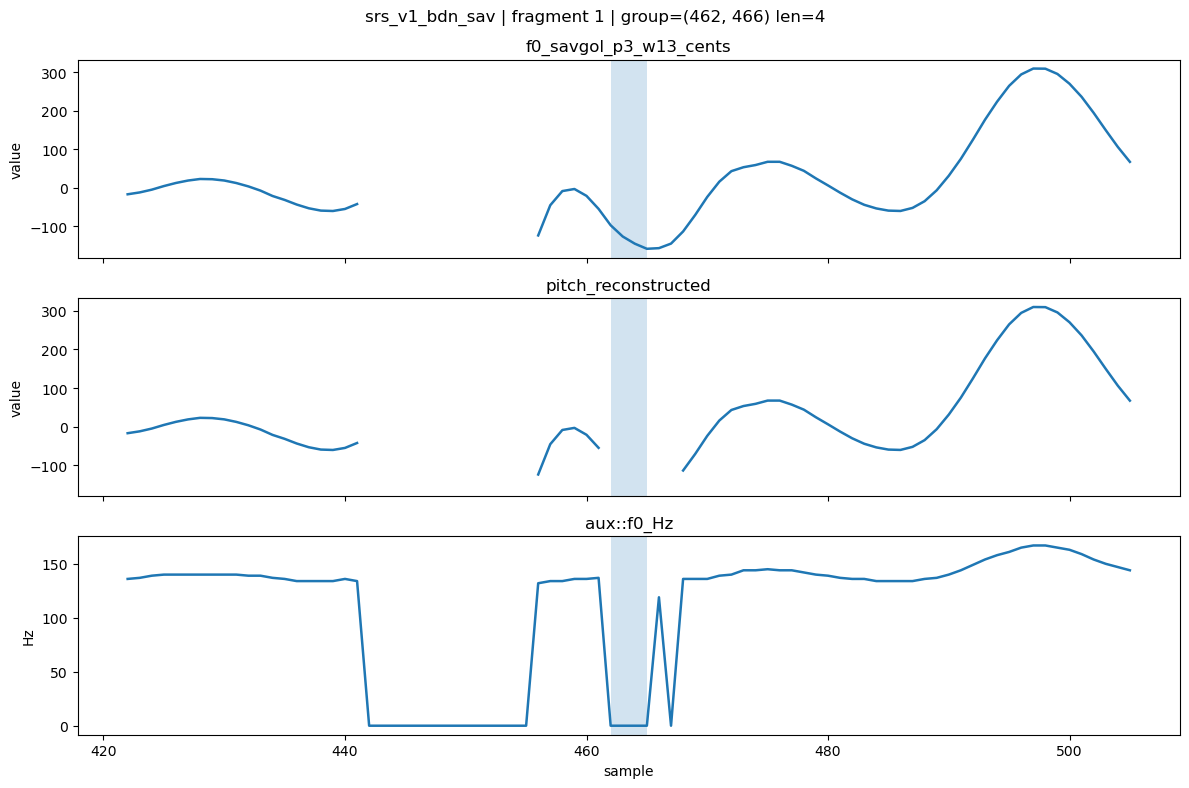

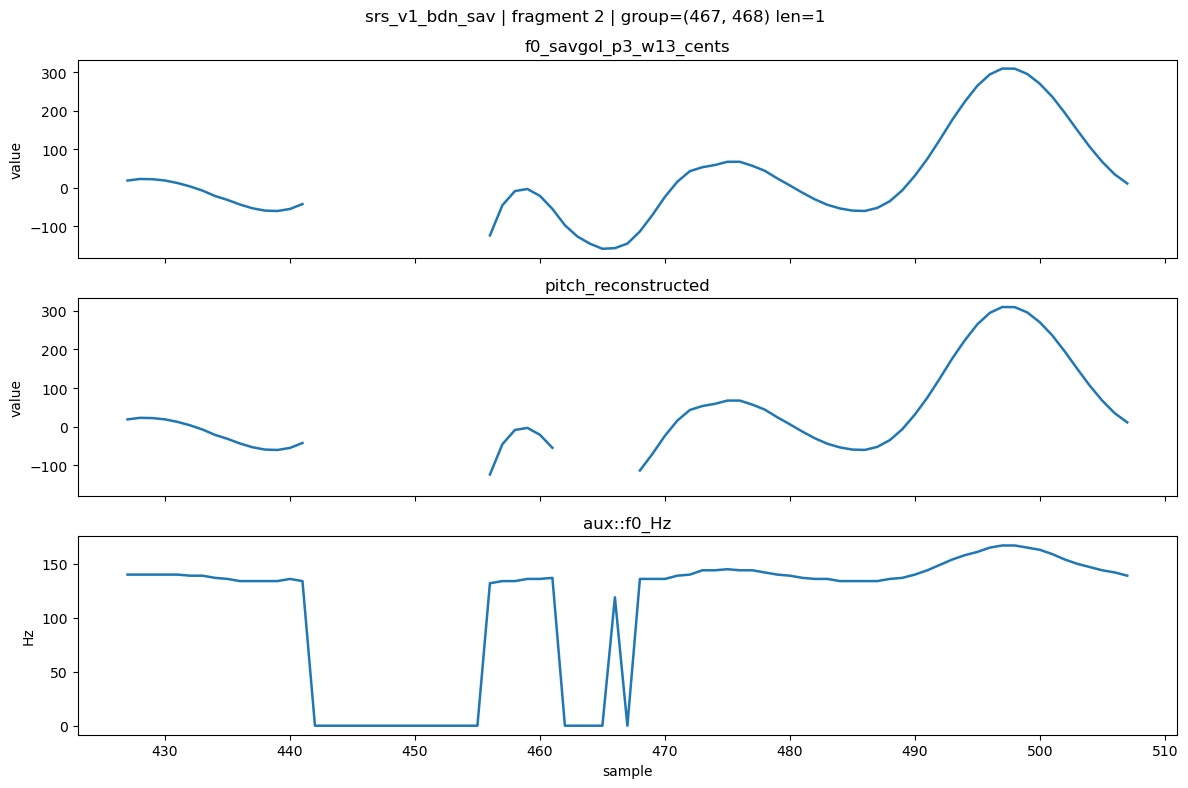

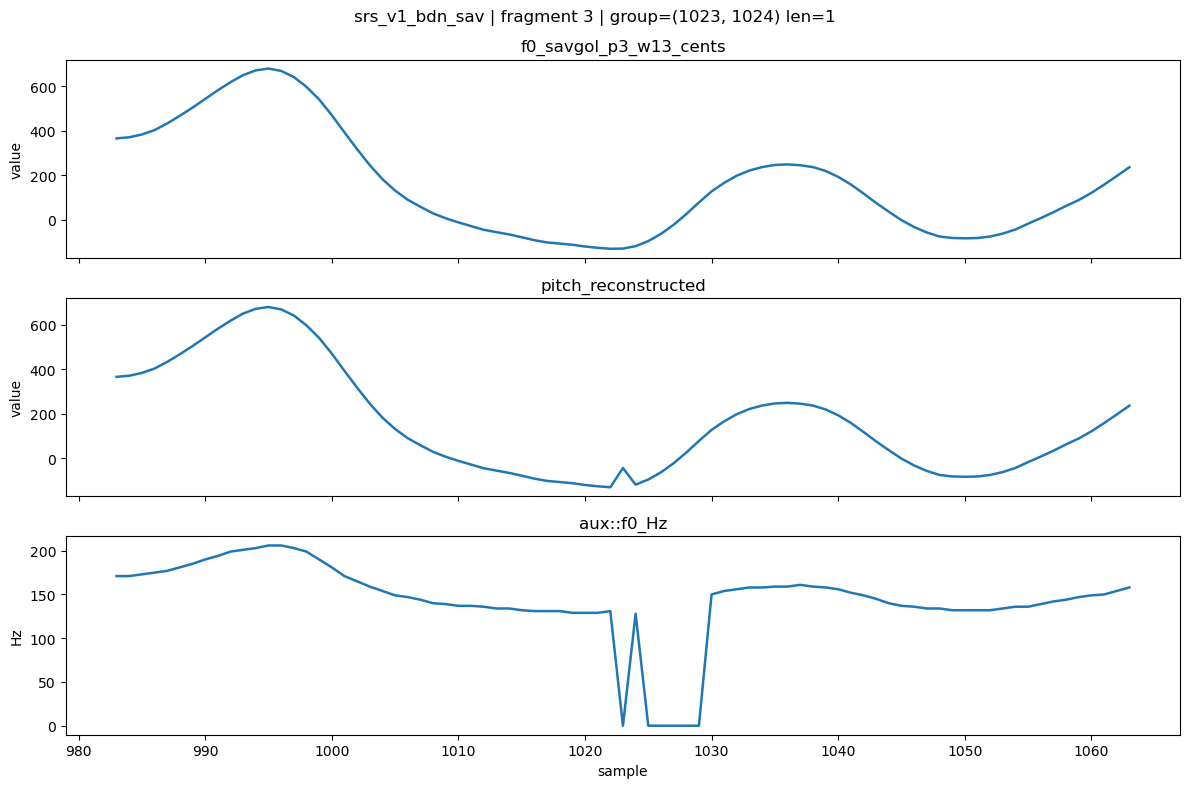

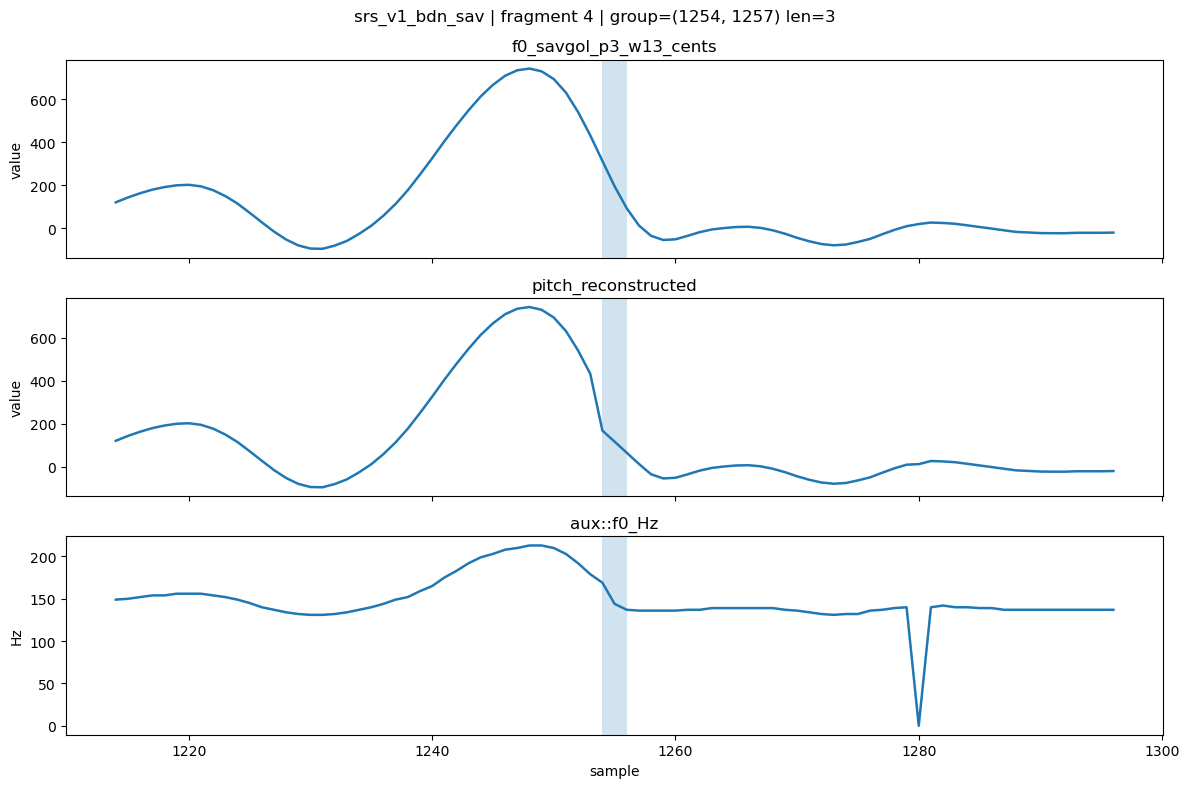

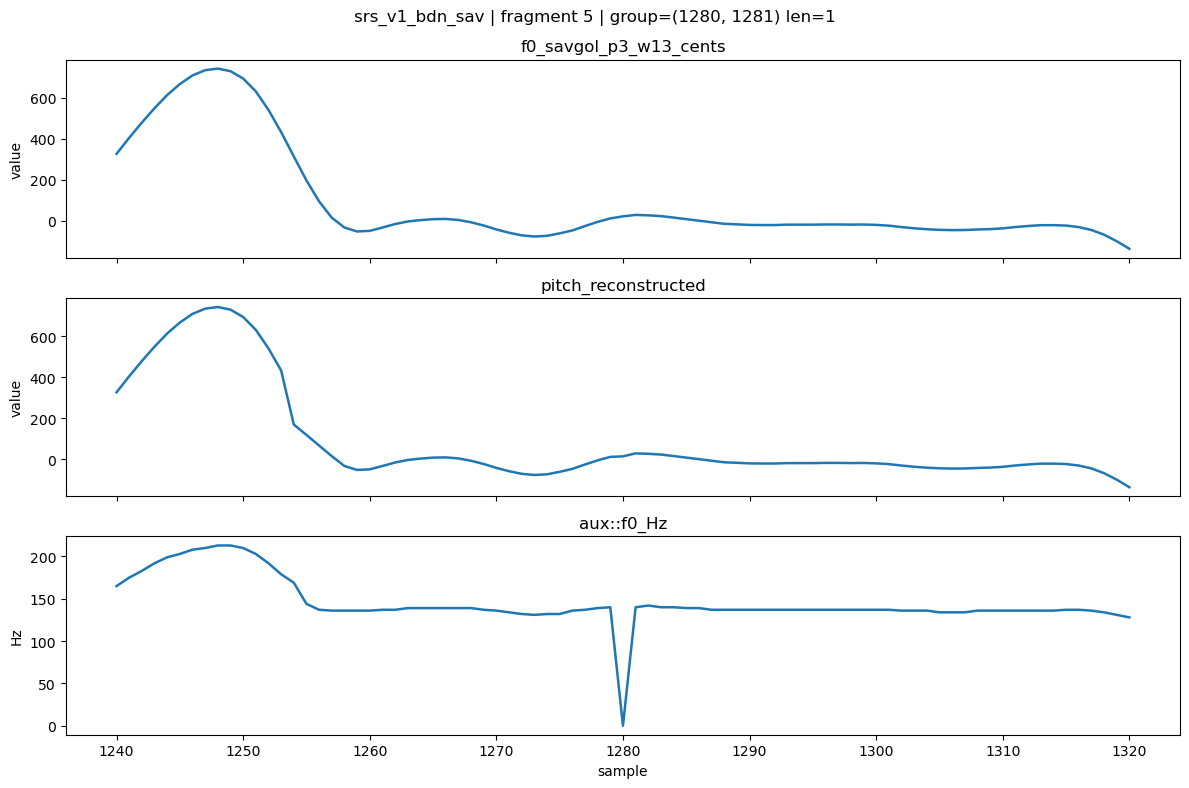

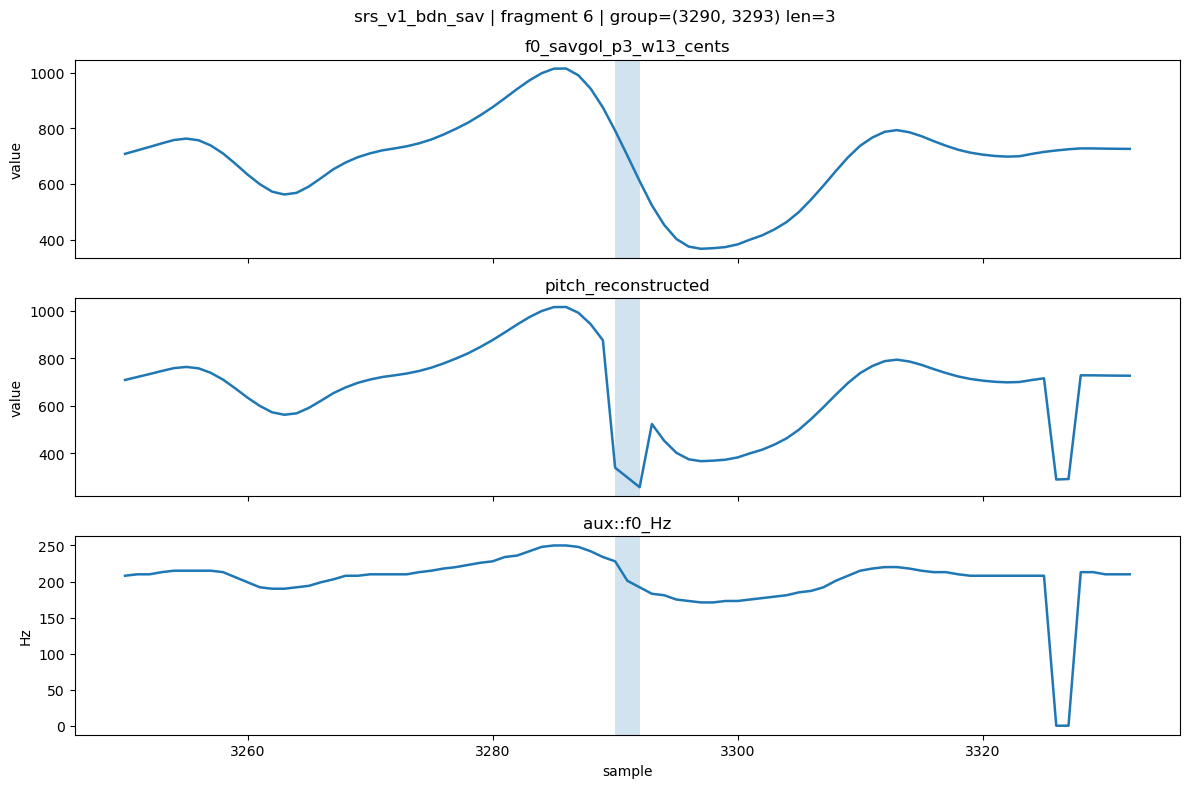

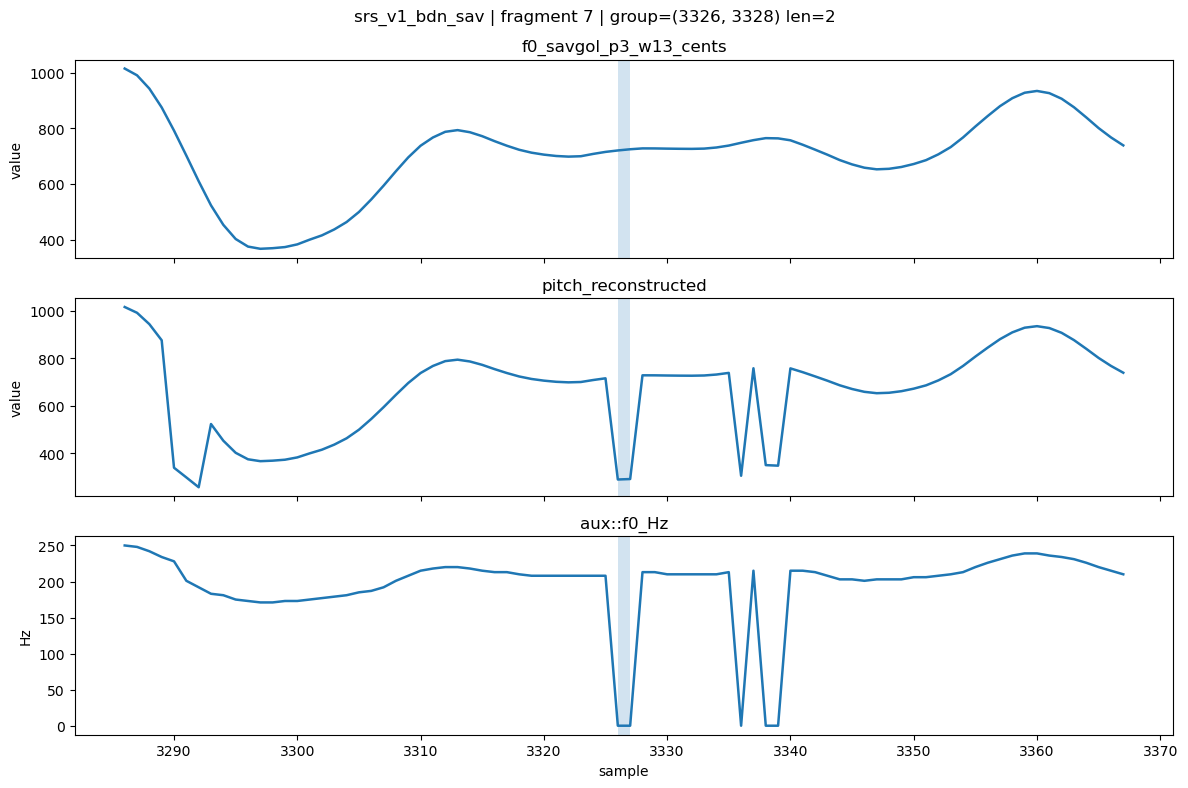

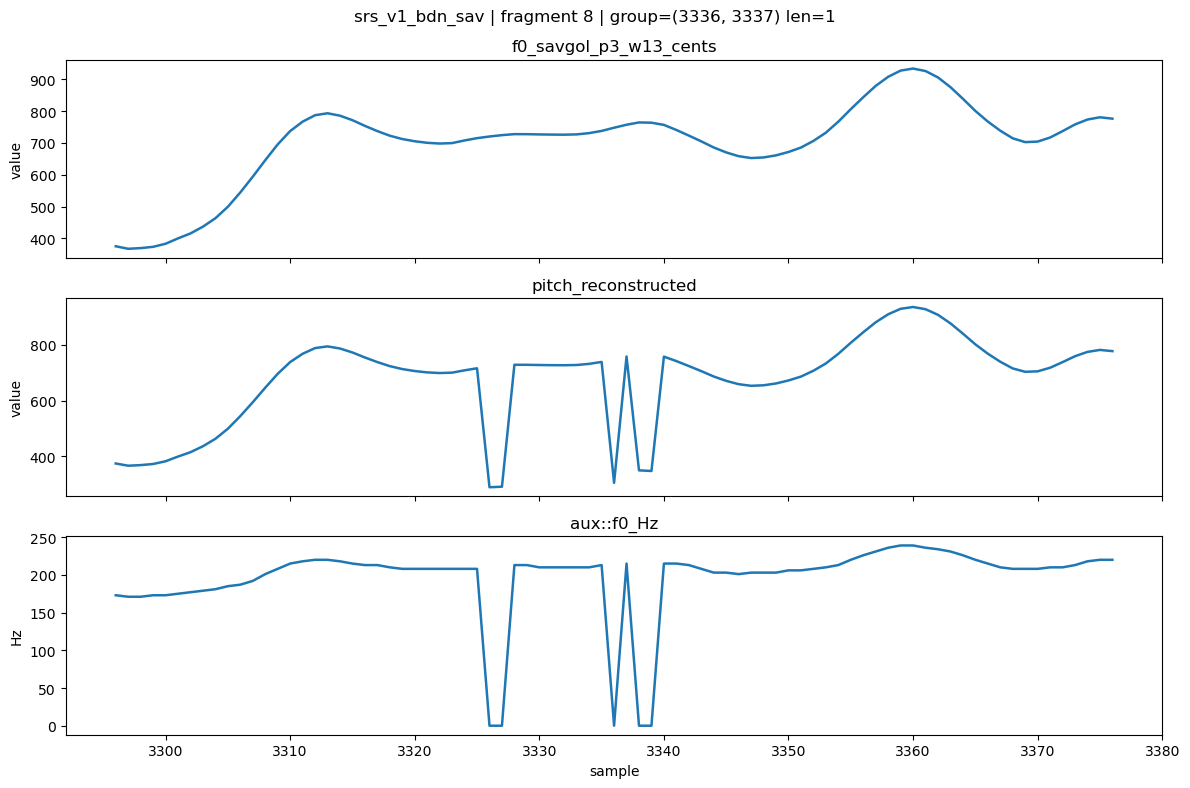

In [10]:
import torch
import torch.nn as nn

recording_id = S.CURRENT_PIECE
tonic_hz = S.SARASUDA_TONICS[S.CURRENT_PIECE]
aux_pitch_path = S.DATA_INTERIM / recording_id / "pitch" / f"{recording_id}_pitch_preprocessed_debug.parquet"
best_ckpt_path = PROJECT_ROOT / "logs" / "pitch_masked_autoencoder_savgol13" / "2026-03-11_16-44-03" / "best_model.pt"


state_dict = torch.load(best_ckpt_path, map_location=DEVICE)

model = ConvMaskedAutoencoder(
    in_channels=2,
    hidden_channels=96,
    dropout=0.05,
)

model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

df_out, groups_all = run_reconstruction_for_recording(
    recording_id=recording_id,
    tonic_hz=tonic_hz,
    aux_pitch_path=aux_pitch_path,
    model=model,
    root_dir=S.DATA_INTERIM,
    device=DEVICE,
    convert_to_cents=False,   # perquè volem comparar en Hz
)